In [1]:
library(scLinaX)
library(ggplot2)
library(ggbeeswarm)
library(dplyr)
setwd("/staging//leuven/stg_00041/Published_StemCell_Data//Pham_EXMC_2022/allelic/")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
#defining colors that I will use for my graphs
XCIcolors <-scale_color_manual(values=c("escapes from XCI"="#9AB1DE", 
                                 "no XCI status known"="grey", 
                                 "PAR"="dark blue",
                                 "subject to XCI"="#FF9777", 
                                 "variably escapes XCI"="#FFE543",
                                       "autosomal" = "black",
                                       "escape"="#4863a3",
                                       "inactive"="#9e4e36",
                                       "variable"="#b59d0e",
                                       "Unknown"="dark grey"))

XCIfill <-scale_fill_manual(values=c("escapes from XCI"="#8AA1CE", 
                                 "no XCI status known"="light grey", 
                                 "PAR"="dark blue",
                                 "subject to XCI"="#FC8767", 
                                 "variably escapes XCI"="#FFD533",
                                       "autosomal" = "dark grey",
                                     "escape"="#8AA1CE",
                                       "inactive"="#FC8767",
                                       "variable"="#FFD533",
                                    "Unknown"="light grey"))

In [3]:
data("XCI_ref")
XCI_ref$XCI_status[which(XCI_ref$Gene=="XIST")] <- "inactive" 

In [6]:
#assuming that you only have one file formatted for sclinax in your folder. Can manually set this to your filename.
inputs <- read.table(list.files("./", pattern="*.formattedForscLinax.tsv")[1], h=T, sep="\t", quote="")

    
    
#adding a filter to remove SNPs that are rarely seen in gnomad and might not be real SNPs
QCfull<-read.table(list.files("./", pattern="hg38_multianno.txt")[1], h=T, sep="\t")
inputs <- inputs[which(inputs$POS%in%QCfull$Start[which(QCfull$gnomad41_genome_AF>0.01)]),]

inputs$Sample_ID <- "SigmaWT"


In [7]:
#make sure that the cell barcodes in the annotation file match the cell barcodes in the input file
EXMCannotation <- read.table("/staging//leuven/stg_00041/Published_StemCell_Data/Pham_EXMC_2022//allelic/timecourse_annotation.tsv", h=T)
EXMCannotation$cell_barcode <- gsub(EXMCannotation$cell_barcode, pattern = "[.]", replacement = "-")
EXMCannotationJustDay <- EXMCannotation
EXMCannotationJustDay$Annotation <- unlist(lapply(EXMCannotation$Annotation, function(x){return(strsplit(x, split="_")[[1]][1])}))


In [8]:
QCref <- run_RefGeneQC(inputs[which(inputs$cell_barcode%in%EXMCannotationJustDay$cell_barcode[which(EXMCannotationJustDay$Annotation%in%c("D8", "D13", "D18", "D70"))]),], 
                       XCI_ref, SAMPLE_NUM_THR=1)


In [9]:
sclinaxResult <- run_scLinaX(ASE_df=inputs,XCI_ref=XCI_ref,QCREF = QCref,
                            Inactive_Gene_ratio_THR=0.15,SNP_DETECTION_DP=10,SNP_DETECTION_MAF=0.05,QC_total_allele_THR=10,
                             HE_allele_cell_number_THR=10,REMOVE_ESCAPE=TRUE,PVAL_THR=0.01,RHO_THR=0.5)

[1] "Start processing of sample 1 (total sample number = 1)"
[1] "Finish processing of sample 1 (total sample number = 1)"


In [13]:
#for the supplemental version the cells are split just by day
combinedScLinaXSummarySplitByDay <- summarize_scLinaX(sclinaxResult, QC_total_allele_THR=10, Annotation=EXMCannotationJustDay)
combinedScLinaXSummarySplitByDay$Day <- factor(combinedScLinaXSummarySplitByDay$Annotation, levels=c("D0", "D1", "D2", "D4", "D8", "D13", "D18", "D70"))
combinedScLinaXSummarySplitByDay$XCI_status[which(combinedScLinaXSummarySplitByDay$XCI_status=="escape")] <- "Escapes from XCI"
combinedScLinaXSummarySplitByDay$XCI_status[which(combinedScLinaXSummarySplitByDay$XCI_status=="inactive")] <- "Subject to XCI"


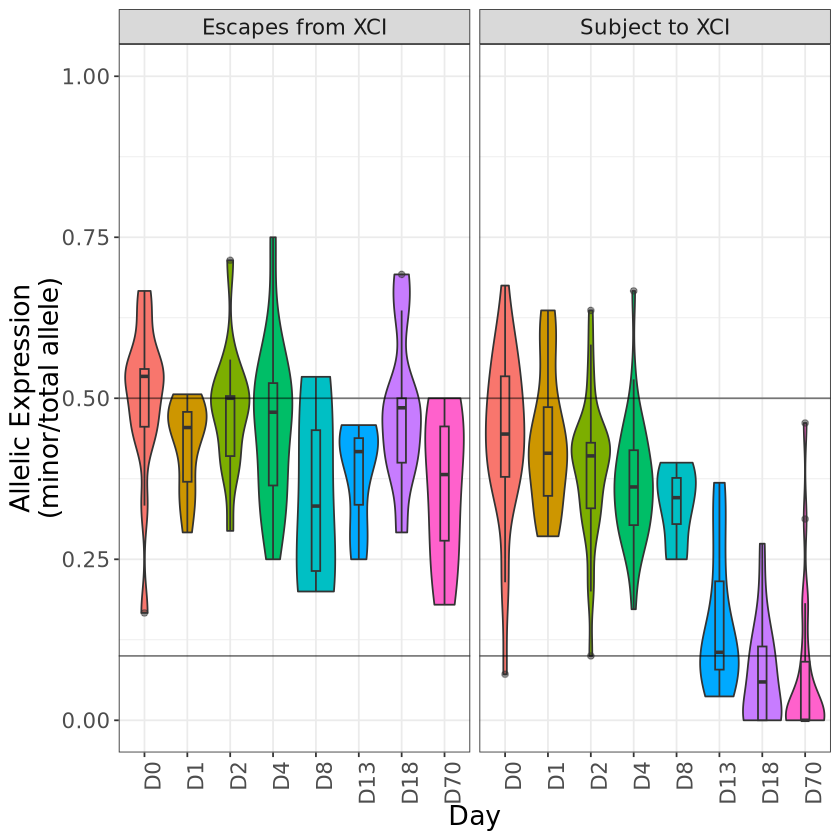

In [19]:
#supplemental Figure 4F
ggplot(combinedScLinaXSummarySplitByDay[which(combinedScLinaXSummarySplitByDay$XCI_status%in%c("Escapes from XCI", "Subject to XCI")),], 
       aes(x=Day, y=minor_allele_ratio, fill=Day))+geom_violin(scale="width", drop=FALSE)+#geom_beeswarm()+
geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=0.5)+theme_bw()+theme(text=element_text(size=16), axis.text.x = element_text(angle=90, hjust=1))+
xlab("Day")+ylab("Allelic Expression\n(minor/total allele)")+
geom_hline(yintercept = c(0.5, 0.1), alpha=0.5)+theme(legend.position="none")+scale_y_continuous(limits = c(0,1))+
facet_wrap(~XCI_status)

In [14]:
#For the main figure version the cells are split by cell type and day
#I am combinging some of the cell annotations from Pham, Panda, et al. to make interpreting the output easier
EXMCannotationCombineCellTypes <- EXMCannotation
EXMCannotationCombineCellTypes$Annotation <- as.character(EXMCannotationCombineCellTypes$Annotation)
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D0_8CLC", "D0_naive"))]<- "D0_naive"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D0_TSC"))]<- "D0_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D1_8CLC", "D1_naive", "D1_intermediate.1","D1_intermediate.3"))]<- "D1_Epiblast"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D1_TSC"))]<- "D1_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D13_early.EXMC"))]<- "D13_EXMC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D13_8CLC", "D13_naive", "D13_intermediate.1","D13_intermediate.2","D13_intermediate.3"))]<- "D13_Epiblast"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D13_TSC"))]<- "D13_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D18_early.EXMC"))]<- "D18_EXMC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D18_TSC"))]<- "D18_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D2_8CLC", "D2_naive", "D2_intermediate.1","D2_intermediate.2","D2_intermediate.3"))]<- "D2_Epiblast"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D2_TSC"))]<- "D2_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D4_8CLC", "D4_naive", "D4_intermediate.1","D4_intermediate.2","D4_intermediate.3"))]<- "D4_Epiblast"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D4_TSC"))]<- "D4_TSC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D70_late.EXMC"))]<- "D70_EXMC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D8_early.EXMC"))]<- "D8_EXMC"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D8_8CLC", "D8_naive", "D8_intermediate.1","D8_intermediate.2","D8_intermediate.3"))]<- "D8_Epiblast"
EXMCannotationCombineCellTypes$Annotation[which(EXMCannotation$Annotation%in%c("D8_TSC"))]<- "D8_TSC"

In [16]:
combinedScLinaXSummary <- summarize_scLinaX(sclinaxResult, QC_total_allele_THR=10, Annotation=EXMCannotationCombineCellTypes)
combinedScLinaXSummary$Day <- unlist(lapply(combinedScLinaXSummary$Annotation, function(x){return(strsplit(x, split="_")[[1]][1])}))
combinedScLinaXSummary$CellType <- unlist(lapply(combinedScLinaXSummary$Annotation, function(x){return(strsplit(x, split="_")[[1]][2])}))
combinedScLinaXSummary$XCI_status[which(combinedScLinaXSummary$XCI_status=="escape")] <- "Escapes from XCI"
combinedScLinaXSummary$XCI_status[which(combinedScLinaXSummary$XCI_status=="inactive")] <- "Subject to XCI"
combinedScLinaXSummary$Day <- factor(combinedScLinaXSummary$Day, levels=c("D0", "D1", "D2", "D4", "D8", "D13", "D18", "D70"))

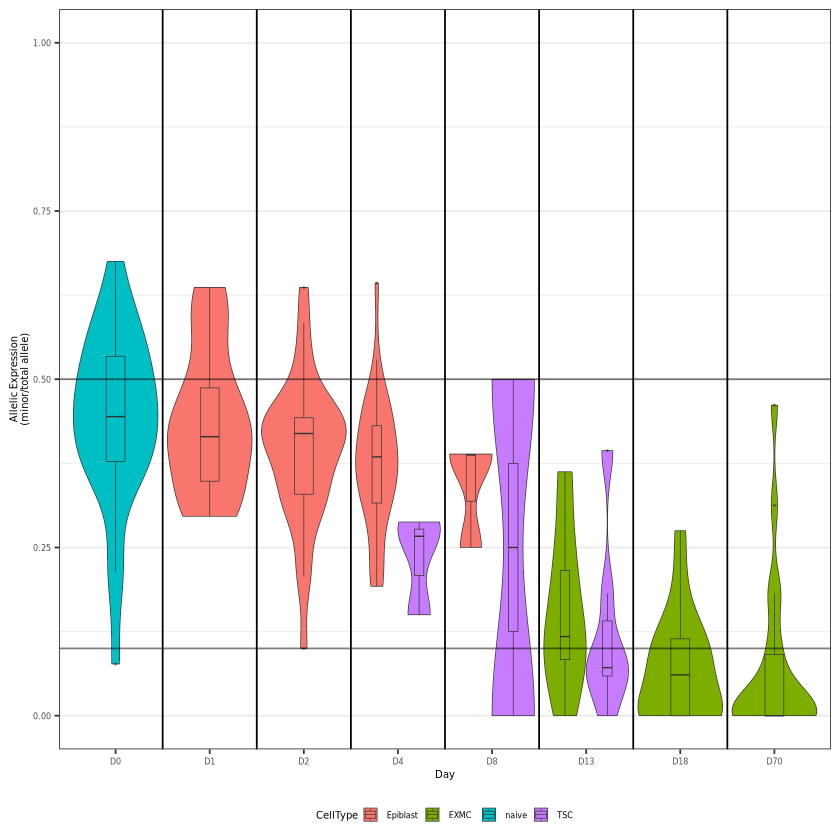

In [18]:
#plotting genes that we expect to be inactive (Figure 3I)
pdf(file = "/data//leuven/343/vsc34313/jupyter_notebooks//XCI/BB-HCA scLinaXhumanCellAtlas/EXMCtimecourse.sclinax.inactiveGenesOnly.wCellType.pdf", width=2.5, height=2)
ggplot(combinedScLinaXSummary[which(combinedScLinaXSummary$XCI_status%in%c("Subject to XCI") &
                                   !combinedScLinaXSummary$Annotation%in%c("D18_TSC")),], 
       aes(x=Day, y=minor_allele_ratio, fill=CellType))+geom_violin(scale="width", drop=FALSE, size=0.2)+#geom_beeswarm()+
geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=0.5, size=0.2, outlier.size = 0.2)+
theme_bw()+theme(text=element_text(size=6), axis.text.x = element_text(angle=0, hjust=0.5, vjust=1),  
                 legend.key.height = unit(x = 0.3, units = "cm"), legend.key.width=unit(x = 0.3, units = "cm"))+
xlab("Day")+ylab("Allelic Expression\n(minor/total allele)")+
geom_hline(yintercept = c(0.5, 0.1), alpha=0.5)+theme(legend.position="bottom", panel.grid.major.x=element_blank())+scale_y_continuous(limits = c(0,1))+
geom_vline(xintercept = c(1:7+0.5))
dev.off()

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


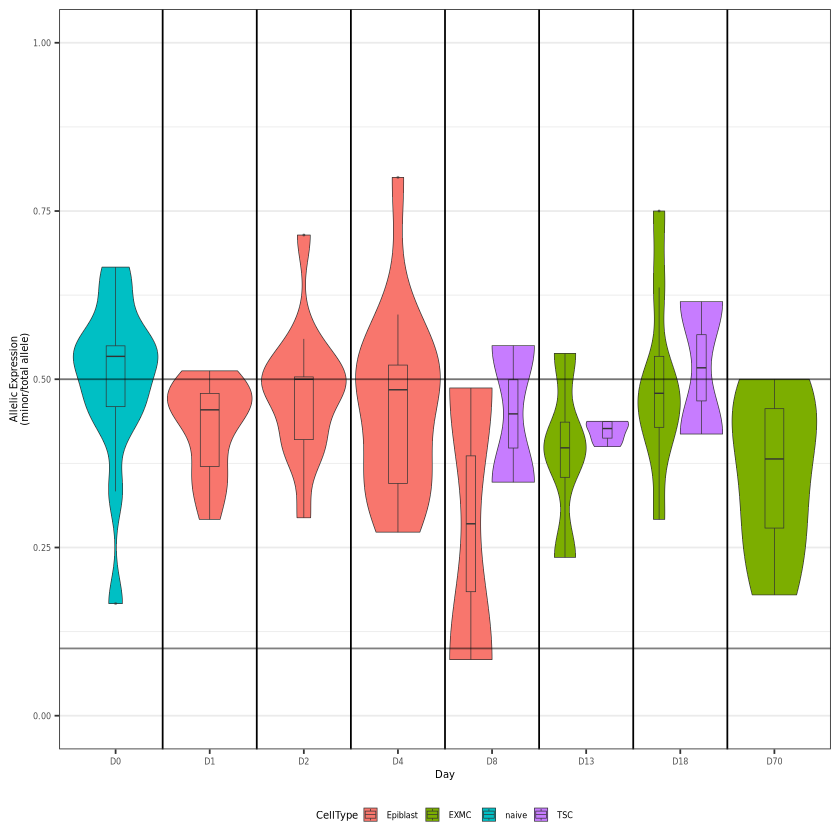

In [17]:
#plotting genes that we expect to escape XCI, Figure S4G
pdf(file = "/data//leuven/343/vsc34313/jupyter_notebooks//XCI/BB-HCA scLinaXhumanCellAtlas/EXMCtimecourse.sclinax.escapeGenesOnly.wCellType.pdf", width=2.5, height=2)
ggplot(combinedScLinaXSummary[which(combinedScLinaXSummary$XCI_status%in%c("Escapes from XCI") &
                                   !combinedScLinaXSummary$Annotation%in%c("D0_TSC","D1_TSC","D13_Epiblast", "D2_TSC", "D4_TSC", "D8_EXMC")),], 
       aes(x=Day, y=minor_allele_ratio, fill=CellType))+geom_violin(scale="width", drop=FALSE, size=0.2)+#geom_beeswarm()+
geom_boxplot(position=position_dodge(0.9), width=0.2, alpha=0.5, size=0.2, outlier.size = 0.2)+
theme_bw()+theme(text=element_text(size=6), axis.text.x = element_text(angle=0, hjust=0.5, vjust=1), 
                 legend.key.height = unit(x = 0.3, units = "cm"), legend.key.width=unit(x = 0.3, units = "cm"))+
xlab("Day")+ylab("Allelic Expression\n(minor/total allele)")+
geom_hline(yintercept = c(0.5, 0.1), alpha=0.5)+theme(legend.position="bottom", panel.grid.major.x=element_blank())+scale_y_continuous(limits = c(0,1))+
geom_vline(xintercept = c(1:7+0.5))
dev.off()